# **AutoEncoders and hidden states Analysis**

Hi, everyone!
In this homework you will get to grips with the idea of using autoencoders to analyse and extract features from the hidden states of a model.

While working through this homework, you will:

- Learn or revise how feature extraction works in Visual Transformers;
- Build and apply an autoencoder to compress the hidden representations learned by a ViT model in the task of classifying cats and dogs;
- Compare ViT and PCA in the feature extraction task.

Let's get started!

In [ ]:
# As always, let's start by importing the libraries we need
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import random
import requests
import os
import seaborn as sns
from io import BytesIO
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from tqdm import tqdm

In [ ]:
torch.manual_seed(7)
torch.cuda.manual_seed(7)
np.random.seed(7)
random.seed(7)

Let's download and open the image.

In [ ]:
# Downloading the image
IMG_PATH = 'https://github.com/SadSabrina/explainable_AI_course/blob/main/HW_module15_hidden_representations/chester.jpg?raw=true'
image_bytes = requests.get(IMG_PATH).content
image = Image.open(BytesIO(image_bytes))

plt.imshow(image)
plt.axis('off');
plt.show()

To make it visually nicer to work with, let's crop and rotate the picture.

In [ ]:
#Let's fix the rotation problem
def rotate_PIL (image, angel, interpolation):
    #PIL.Image.NEAREST (use nearest neighbour), PIL.Image.BILINEAR (linear interpolation in a 2×2 environment), or PIL.Image.BICUBIC
    return image.rotate(angel, interpolation)

image = image.crop((500, 0, 4000, 3000))
image = rotate_PIL(image, -90, Image.BICUBIC)

In [ ]:
plt.imshow(np.array(image))
plt.axis('off')
plt.show()

Great, we have loaded the picture and brought it back to its senses.

Now let's load the model. You can load the model from HF — that option is already written in the code. If it does not work out, you need to:
1. download the `cat_dog_model` folder from [this link](https://drive.google.com/drive/folders/1TztlM4sC0HRJmhZyMltRIGZP1exGRHt5?usp=sharing);
2.  point `MODEL_PATH` at the folder with the files
3. run the loading.

In [ ]:
# The model is taken from here: https://huggingface.co/akahana/vit-base-cats-vs-dogs
#MODEL_PATH = 'YOUR_PATH_TO_THE_FOLDER'

MODEL_PATH_HF = 'akahana/vit-base-cats-vs-dogs'

# Loading the pretrained feature extractor and the classification model
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
model = ViTForImageClassification.from_pretrained(MODEL_PATH_HF)

model.eval();

# **More about ViT**

Before we move on to building an autoencoder, analysing hidden representations or any other task that involves analysing a model, we need to understand what we are going to work with, what features we will have at the input and at which stage they are extracted from the network.  

### **1. Features.**

When we analysed vector representations of text represented by tokens, in the lesson on probing, the shape of the hidden states for texts was this: `(batch_size, sequence_length, hidden_dim)`. That is, for a single sentence of 6 tokens the dimensions were `(1, 6, 1024)` — 6 tokens, each represented by a 1024-dimensional vector.

So it turns out that when working with text we work with 1D token vectors of some fixed length. And in general it is convenient for us to apply compressing transformations to them straight away, PCA for example. But what about images? Let's look at how a picture is represented in ViT.

### **Images into features. The idea of patches**

The intuitive and basic approach to representing an image in a form convenient for analysis and vectorisation is to take the image and flatten it to 1D. Then, if our image is 8x8 — everything is fine, and flattening gives a vector of length 64.

However, this approach turns out not to work when the image is a bit larger, say 64x64. Then its dimensionality in 1D is already 4096, and on top of that every pixel would have to be linked to every other one (that is, $4096^2$ connections).

And so, gathering together what we do not like and some analogies from the representation of text sequences, it turns out that we want:
- Every image to be reflected by several vectors;
- Each of those vectors to have a fixed and reasonable (set by us) dimensionality;

**Patches in ViT.**

In ViT (Visual Transformers) — one of the significant architectures of 2021 ([paper](https://arxiv.org/abs/2010.11929)) — these problems are solved with the help of patches.

Patches are built like this:

1. We take a picture $H, W, C$ – height, width, number of channels  (1)
2. We cut it into $N$ patches. Each of the patches is a "square" on the image, with dimensions $p, p, c$, where $p$ is the side of the square (2)
3. We flatten these patches into a vector, which gives N vectors of dimensionality $p^2*C$ (3)
4. The array of patches, of dimensionality $(N, p^2*C)$, is multiplied by a learnable tensor
with dimensions  $(p^2*C, d)$  (4)
5. As a result we get N patches with dimensions $(1, d)$  (5)
6. We add a $[cls]$ token, similar to BERT (a picture and an intuitive answer [here](https://stackoverflow.com/questions/62705268/why-bert-transformer-uses-cls-token-for-classification-instead-of-average-over), with dimensionality $(1, d)$, so in total our input is $(N+1, d)$ patches (6)
6. Finally, to every patch we add a positional embedding with the very same dimensionality $(1, d)$ (7)

And there we have cooked up the features, which then go on into the encoder layers.


![patches](https://user-images.githubusercontent.com/42609155/128160932-6c92920e-b996-4208-9f71-c5caeb4d7285.png)


**How many vectors does an image actually correspond to in practice, and what is their dimensionality?**

The dimensionality of the parameter vector (that is, d in the notation above) of ViT is a fixed parameter. By default the vector has length 768, so if the input image consists of 1 channel and has dimensions $(h, w) = (224, 224)$, then in order to count how many vectors will characterise it, we need to choose:

1. The number of patches to split into, $k$
2. The size of the patches, $p$

We choose the number and the size so that $h=w=p\cdot k$. Then if there are 14 patches along one side, as in the example, the number of vectors encoding the image is:

$$cnt = \frac{h}{p}*\frac{w}{p} = p * p = 14 * 14 = 196$$

The image is split with the help of a convolution with kernel $kernel=(p, p)$ and a step (stride) such that $stride=(p, p)$.

And there we are, our image will be represented by $197$ vectors ($196$ for the patches, plus cls) of dimensionality $768$!

**Task 1. Suppose the input picture has size 168*168 and the number of patches is 12. What is the number of vectors encoding the image? Do not forget about [CLS].**

Answer: **Your answer here**

### **2. Analysing the structure**

Now, before extracting the features — let's say we already know their sizes — we need to understand where they will be pulled out from. For that, let's look at the structure of the model.

We will not have to implement the extraction itself by hand, since the hidden states can be obtained by specifying a hyperparameter at inference time.

**Task 2. Call the ._modules attribute on the model. How many top-level modules did you manage to find?**

In [ ]:
# Your code here

**Task 3. Now, going step by step into the parts of the first component you found in the task above, answer: how many `layer` layers are there in the encoder component of the model?**

In [ ]:
# Your code here

Let's fix the fact that the main model consists of a sequence of encoders and a classifier. Now let's analyse what the hidden states will look like.

In the transformers library, returning the hidden states can be obtained with a simple attribute at inference time.

The syntax is roughly this:



```
model = Net()
outputs = model(**inputs, output_hidden_states=True)

```


Let's do the feature extraction on a single example. For that we will:
1. Convert the input picture into features with `ViTImageProcessor`;
2. Pass the resulting image through the model;
3. Look at the hidden states we get.

In [ ]:
# Preparing the input data
inputs = feature_extractor(images=image, return_tensors="pt", do_convert_rgb=True, do_normalize=False)

# Let's look at the form in which the image will be passed through the model
featured_image = inputs['pixel_values'][0].permute(1, 2, 0)

fig, ax = plt.subplots(figsize=(12, 6))
plt.imshow(featured_image)
plt.axis('off');

Now let's run the prediction.

In [ ]:
# Making the prediction
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# Getting the predicted class
predicted_class_idx = torch.sigmoid(outputs.logits).argmax(-1).item()
labels = model.config.id2label  # Dictionary of indices and classes

print(f"Predicted class: {labels[predicted_class_idx]}")

**Task 4. Analyse the class probabilities returned by the model. By how much did the `dog` class exceed the `cat` class? Do not round the answer — write down all the digits.**

In [ ]:
torch.sigmoid(outputs.logits)

In [ ]:
0.5887 - 0.4255

In [ ]:
print(f'Number of hidden states: {len(outputs.hidden_states)}')
print(f'Dimensionality of each state: {outputs.hidden_states[0].shape}')

Hooray! Even though the prediction is wrong, we have extracted everything. The number of hidden states is 13, where

* The first one ('outputs.hidden_states[0]') is the output of the embedding part `model.vit.embeddings`
* States 2-13 are the outputs of the encoder parts — all of them before the very last layer of the `model.vit` component, `layernorm`, is applied to them

**Important:**

In some models, when you specify `output_hidden_states=True`, `last_hidden_state` is returned as well. In the general case, `outputs.last_hidden_state != outputs.hidden_states[-1]`, since what is stored in `outputs.last_hidden_state` reflects the hidden state after `layernorm`

Now that we have understood the output for a single picture, we can run several through. Let's say 300 cats and dogs — they will take about 5 minutes to run. To do this, you can download the data from the drive [here](https://drive.google.com/drive/folders/1TztlM4sC0HRJmhZyMltRIGZP1exGRHt5?usp=sharing).

In [ ]:
# Specifying the path to the folder with images
image_folder = "YOUR_PATH_TO_THE_FOLDER test_cats_dogs"


# Preparing the lists for the data
last_hidden_states_list = []
mid_hidden_states_list = []
labels_list = []
probas_list = []

images_list = os.listdir(image_folder)
images_sample = random.sample(images_list, 300)

# Going through all the files in the folder
for filename in tqdm(os.listdir(image_folder)[:300]):
    if filename.endswith((".jpg", ".png", ".jpeg")):  # Filtering the images
        image_path = os.path.join(image_folder, filename)
        image = Image.open(image_path).convert("RGB")  # Opening the image

        # Processing the image with the feature extractor
        inputs = feature_extractor(images=image, return_tensors="pt")

        # Getting the hidden states
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            features = model.vit(**inputs).last_hidden_state[:, 1:, :] # the representation of the image before it is fed into the classifier
            mid_features = outputs.hidden_states[len(outputs.hidden_states) // 2][:, 1:, :]  # The last layer (dimensionality: batch x patches x hidden_dim)

        predicted_class_idx = outputs.logits.argmax(-1).item()
        predicted_probas = torch.sigmoid(outputs.logits)
        predicted_class_proba = predicted_probas.max().item()

        labels = model.config.id2label  # Dictionary of indices and classes
        label = labels[predicted_class_idx]

        # Adding the hidden states and the label to the list
        last_hidden_states_list.append(features.squeeze(0))  # Removing the batch dimension
        mid_hidden_states_list.append(mid_features.squeeze(0))
        labels_list.append(label)
        probas_list.append(predicted_class_proba)

In [ ]:
# Converting into tensors
last_hidden_states_tensor = torch.stack(last_hidden_states_list)  # Dimensionality: (num_images, hidden_dim)

mid_hidden_states_tensor = torch.stack(mid_hidden_states_list)

Now let's sum up what we have. For each of the 1000 pictures we have a $197$x$768$ matrix. In this format it is not convenient to analyse the features and to separate them somehow for two classes.  How can we understand whether the model has separated the classes in space?

For that we can apply an autoencoder!

## **Autoencoder**

Let me remind you that the simplest autoencoder looks like this:

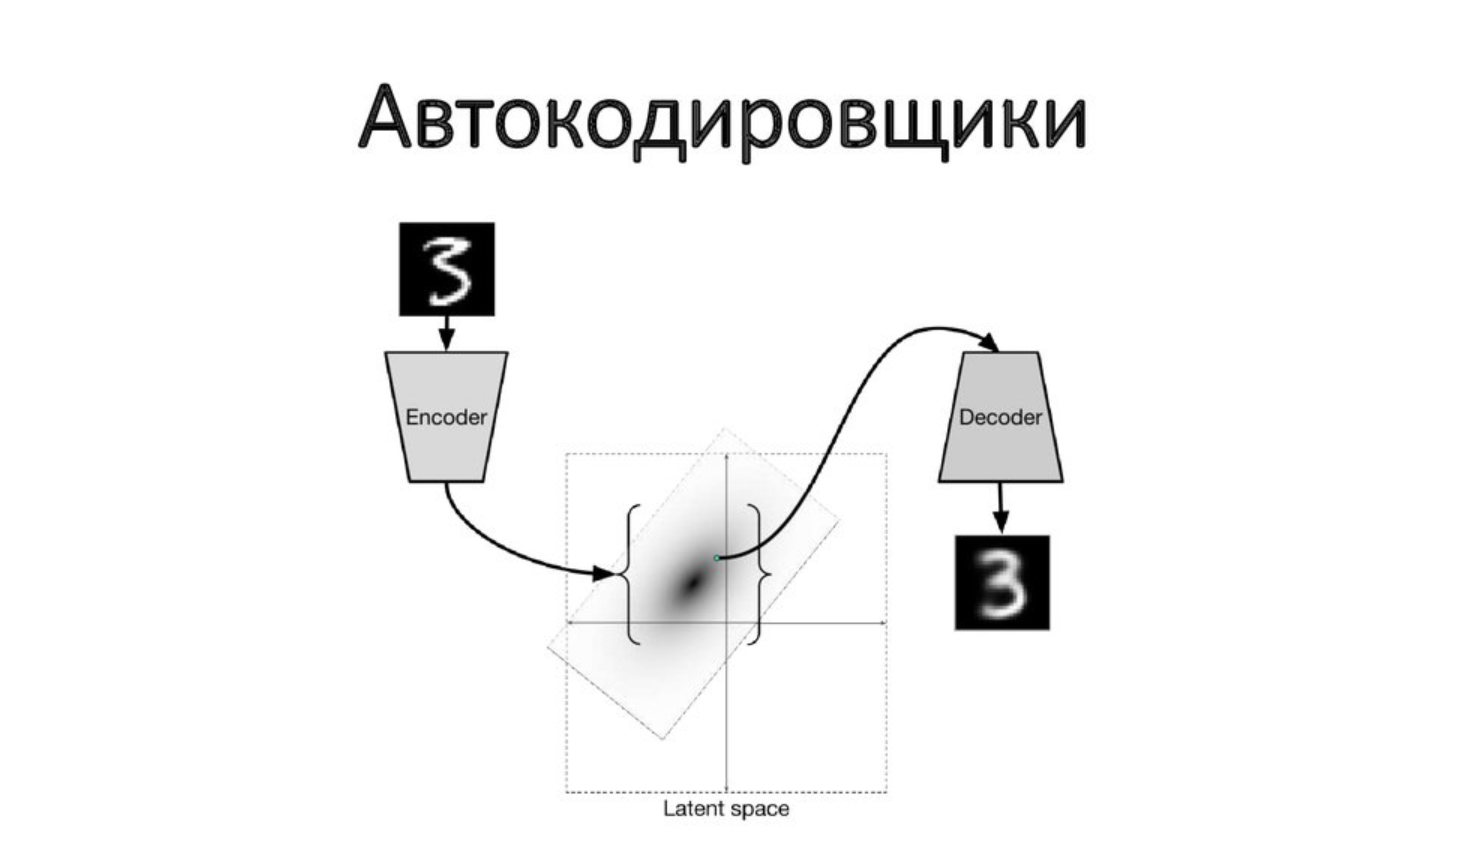

 Let's implement it in code as two components, as in the picture — an encoder and a decoder. We will write simple classes for them following this logic:

 * We have 196 patches with 768 features, since the CLS representation was not extracted. Such a structure can be viewed as a matrix, which means we can run a convolution over it.

* We need to compress the original image down to a form that is convenient to visualise. The best format is to leave two features for each original image.

**To achieve the goal of representing each picture as a vector of two numbers, we can go several ways:**

1. Leave the number of patches as it is, since every group of 196 patches == one image, and work with the dimensionality of the hidden representation — 768, compressing it with a convolution.

2. Treat the matrix as a monolithic data structure and compress it with a two-dimensional convolution. In that case, however, it is important to choose the architecture carefully, so as to restore the structure back to its initial sizes and be able to compute the loss.

To get acquainted with the autoencoder architecture, let's implement option 1.

**Task 5. Finish the autoencoder architecture below. The first and the second convolutions are already filled in in the code. Implement the remaining ones following the rule — each next convolution halves the previous one. In your answer, write down how many convolution layers you had to add. Do not forget to add a ReLU after the convolutions.**

(The first convolution is implemented differently, because dividing 768 by 2 repeatedly would leave us with 3 features at the last iteration).

Answer: **Your answer here**

In [ ]:
#Implementation of option 1

class PatchEncoder(nn.Module):
    def __init__(self, D_latent=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(768, 512, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(512, 256, kernel_size=1),
            nn.ReLU(),

            # Your code here

        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, 768, 196] for Conv1d
        return self.encoder(x).permute(0, 2, 1)  # [B, 196, D_latent]


class PatchDecoder(nn.Module):
    def __init__(self, D_latent=128):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv1d(D_latent, 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(4, 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=1),  # Restoring the dimensionality
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(256, 512, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(512, 768, kernel_size=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, D_latent, 196]
        return self.decoder(x).permute(0, 2, 1)  # [B, 196, 768]


class PatchAutoencoder(nn.Module):
    def __init__(self, D_latent=128):
        super().__init__()
        self.encoder = PatchEncoder(D_latent)
        self.decoder = PatchDecoder(D_latent)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

The model is ready. In it we successively reduce the features with the help of convolutions. When applying an autoencoder to hidden states, the idea is this:

*if the autoencoder manages to converge during training, then we get a representation that reflects the compressed features from the model*.

All right then. Now let's prepare the data and train the autoencoder.

### **Preparing the data**

When extracting the features, we will rely not on the ground truth classes, but on the ones the model predicted. We collected them above.

**Why exactly like that?** \
The statement of the feature extraction task is always about extracting information *from the model*, which means it is correct to rely only on the information that is embedded in it. When analysing features, the hypothesis is this — the predicted class corresponds to the model's "opinion" based on its knowledge about the image.

In [ ]:
# Preparing the classes

func = lambda x: 1 if x =='cat' else 0
inv_func = lambda x: 'cat' if x == 1 else 'dog'

labels_list = [func(i) for i in labels_list]

In [ ]:
labels_tensor = torch.tensor(labels_list)  # Dimensionality: (num_images,)

# Saving the hidden states and the labels, so that we do not have to obtain them again every time
torch.save(last_hidden_states_tensor, "last_hidden_states.pt")
torch.save(mid_hidden_states_tensor, "mid_last_hidden_states.pt")

torch.save(labels_tensor, "labels.pt")

print(f"Saved {len(last_hidden_states_tensor)} hidden states. Tensor size: {last_hidden_states_tensor.shape}")
print(f"Saved {len(mid_hidden_states_tensor)} hidden states. Tensor size: {mid_hidden_states_tensor.shape}")

Now let's launch the training on the hidden states. Above we collected two of them: the last one (in `last_hidden_states_list`) and the middle one (in `mid_hidden_states_list`)

In [ ]:
autoencoder = PatchAutoencoder(D_latent=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
num_epochs = 10

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = autoencoder(last_hidden_states_tensor)  # [B, 196, 768]
    loss = criterion(outputs, last_hidden_states_tensor)
    loss.backward()
    optimizer.step()
    print(loss)

Judging by the decrease of the loss, the training happened. It has not, of course, moved significantly away from the starting point, but the result is worth checking. For that, let's extract the hidden representations and take the median over the patches, in order to get an $m \times n$ matrix, where $m$ is the number of rows (examples) and $n$ is the median of each patch.

In [ ]:
latent = autoencoder.encoder(last_hidden_states_tensor)
print(latent.shape)
latent_med = np.median(latent.detach().numpy(), axis=1)
latent_med.shape

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=latent_med[:, 0], y=latent_med[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

**Task 6. Try applying summation and averaging along the patch axis. Did you get the same linearly separable result?**

- Yes, for the mean
- Yes, for the sum
- Yes, for both arithmetic operations
- No

In [ ]:
latent = autoencoder.encoder(last_hidden_states_tensor)
latent_mean = np.mean(latent.detach().numpy(), axis=1)
latent_mean.shape

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=latent_mean[:, 0], y=latent_mean[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

In [ ]:
latent = autoencoder.encoder(last_hidden_states_tensor)
latent_sum = np.sum(latent.detach().numpy(), axis=1)
latent_sum.shape

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=latent_sum[:, 0], y=latent_sum[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

**Task 7. Now check what the projection of the features onto the plane looks like at the middle hidden layers. For that, complete the autoencoder training code below. Did the model start training?**

**Your answer here**

In [ ]:
# Middle patches

mid_autoencoder = PatchAutoencoder(D_latent=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mid_autoencoder(mid_hidden_states_tensor)  # [B, 196, 768]
    loss = criterion(outputs, mid_hidden_states_tensor)
    loss.backward()
    optimizer.step()
    print(loss)

In [ ]:
mid_latent = mid_autoencoder.encoder(mid_hidden_states_tensor)
mid_latent_med = np.median(mid_latent.detach().numpy(), axis=1)
mid_latent_med.shape

In [ ]:
# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=mid_latent_med[:, 0], y=mid_latent_med[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

At the middle layers we see an absence of separation.

### **PCA**

As a final push, let's look at how PCA would have coped with this task. On the same hidden states we will fit the principal components method, so that:

1. First we take the median over the patches — that gives 768 features for each object;
2. On the resulting features we fit PCA, asking for two components;
3. We analyse the result.

In [ ]:
original_hid_states = np.median(last_hidden_states_tensor.detach().numpy(), axis=1)

pca = PCA(n_components=2, random_state=42)
orig_latent_2d = pca.fit_transform(original_hid_states)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=orig_latent_2d[:, 0], y=orig_latent_2d[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.legend()
plt.title("2D Visualization of Latent Space")
plt.show()

**Task 8. Approximately what share of the variance is explained by the two components found at the last layers? Round the answer to two decimal places. `pca.explained_variance_ratio` will help you**

In [ ]:
# Your code here

Similarly, let's look at the middle layers.

In [ ]:
mid_original_hid_states = np.median(mid_hidden_states_tensor.detach().numpy(), axis=1)

pca = PCA(n_components=2, random_state=42)
mid_orig_latent_2d = pca.fit_transform(mid_original_hid_states)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=mid_orig_latent_2d[:, 0], y=mid_orig_latent_2d[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.legend()
plt.title("2D Visualization of Latent Space")
plt.show()

**Task 9. What share of the variance is explained by the two components found at the middle layers? Round the answer to two decimal places. `pca.explained_variance_ratio` will help you**

In [ ]:
# Your code here

### **Results and conclusions**

Let's fix what we got.

1. First a trained model was taken.

2. On the test data for this model we extracted:

* the predictions;
* the hidden states of the last layer;
* the hidden states of the middle layer;

3. On the hidden states an autoencoder was trained, with the central dimensionality between the encoder and decoder components equal to 2.

4. We used the two-component representation to assess how well separated from each other the features of the classes predicted by the model are (two components, because that way it can be drawn on a plane).

The visualisations showed that the model separates the feature representations well at the last hidden state and almost does not separate them at the middle one. From this we can put forward a hypothesis about gradual disentangling as the depth of the network increases (and the middle layer separates the classes rather poorly).

5. For a comparative analysis we applied PCA and were able to extract results similar to the autoencoder's, several times faster.

**As an important conclusion:** for simple dependencies and simple tasks (such as binary classification), `PCA` is a faster and more convenient tool from the point of view of a high-level analysis of the model.

**Note:**

In fact, the conclusion of this particular study cannot be generalised to all models, nor should we assume that middle hidden states do not encode rich representations. On the contrary, for example here, in [Layer by Layer: Uncovering Hidden Representations in Language Models](https://arxiv.org/pdf/2502.02013), the authors show that intermediate layers can encode even richer representations than the last ones, showing good performance across a wide range of subtasks. Another interesting example: here, in [Probing Latent Subspaces in LLM for AI Security: Identifying and Manipulating Adversarial States](https://arxiv.org/pdf/2503.09066), they extract a direction that produces a jailbreak, also from an intermediate layer. There is a lot of interesting stuff inside =)